# Neural PDE Laboratory · 07
## Heat flow and parameter-conditioned PINNs

Experiments **12–13** of the laboratory. This notebook is self-contained:
run it in a fresh kernel; no earlier notebook or saved result is required.

[All seven notebooks](Neural_PDE_Laboratory.ipynb) · [Setup and guide](NOTEBOOK_README.md)

Install `experiments/requirements-notebook.txt`, then select **Restart Kernel and
Run All Cells**. The supplied static plots and diagnostics can be read on GitHub.
Interactive explorers are separate, self-contained HTML files in `notebook_outputs/`;
download that folder and open `index.html` in a browser, or regenerate them locally.

Python 3.11+; CPU / float64. Set `RUN_MODE = "thorough"` for longer training runs.

**Notation:** $u$ is the reference state, $u_\theta$ the neural state,
$r_\theta=\mathcal L u_\theta-f$, $\mathcal J$ a continuous residual loss,
$\widehat{\mathcal J}$ its numerical approximation, and $\mathcal E$ an energy.
A hat indicates sampling or quadrature. We check solution error separately from training loss.

In [1]:
# Uncomment only if these packages are missing, then restart the kernel.
# %pip install "numpy>=2.0" scipy matplotlib "torch>=2.2" "plotly>=5.24,<7" ipython

In [2]:
from pathlib import Path
import copy, io, json, math, platform, time
import numpy as np
import scipy
from scipy.linalg import solve_banded
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import torch
from torch import nn
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown, Image

RUN_MODE = "quick"               # "quick" or "thorough"
SEED = 7
OUTPUT_DIR = Path.cwd() / "notebook_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
NOTEBOOK_START = time.perf_counter()
metrics = []
FIGURE_NAMES, INTERACTIVE_NAMES = [], []
assert RUN_MODE in {"quick", "thorough"}
torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
torch.manual_seed(SEED)
np.random.seed(SEED)
BUDGET = {"adam_1d": 900, "lbfgs_1d": 180, "adam_2d": 1100,
          "lbfgs_2d": 260, "boundary_adam": 900}
if RUN_MODE == "thorough":
    BUDGET = {key: 2 * value for key, value in BUDGET.items()}
versions = {"python": platform.python_version(), "numpy": np.__version__,
            "scipy": scipy.__version__, "matplotlib": matplotlib.__version__,
            "torch": torch.__version__, "plotly": plotly.__version__}
print(json.dumps(versions, indent=2))
print(f"CPU / float64 / seed {SEED} / {RUN_MODE} mode")

{
  "python": "3.13.9",
  "numpy": "2.4.2",
  "scipy": "1.17.0",
  "matplotlib": "3.10.8",
  "torch": "2.10.0",
  "plotly": "6.9.0"
}
CPU / float64 / seed 7 / quick mode


## Reading and saving the plots

Static figures are saved as PNG and PDF and embedded in this notebook. Interactive
plots are saved as offline HTML files: open their links locally to rotate, zoom,
and animate them. GitHub displays the static figures without executing JavaScript.

In [3]:
palette = {"navy": "#10243A", "teal": "#00A6A6", "orange": "#F28C45",
           "pink": "#DC4778", "blue": "#4878D0", "ink": "#183449", "muted": "#63788A"}
plt.rcParams.update({
    "figure.facecolor": "#F7FAFC", "axes.facecolor": "#F7FAFC",
    "axes.edgecolor": "#CAD6DF", "axes.labelcolor": palette["ink"],
    "text.color": palette["ink"], "xtick.color": palette["muted"],
    "ytick.color": palette["muted"], "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#DCE5EB", "grid.alpha": 0.65,
    "lines.linewidth": 2.3, "figure.dpi": 110, "savefig.dpi": 170,
    "legend.frameon": False, "font.family": "DejaVu Sans",
    "axes.prop_cycle": matplotlib.cycler(color=[palette[k] for k in
                                  ["teal", "orange", "pink", "blue", "navy"]]),
})
sea_cmap = LinearSegmentedColormap.from_list("sea", ["#10243A", "#146F88", "#00BBB0", "#F9D879"])
wave_scale = [[0, "#153F7C"], [.25, "#21A9B5"], [.5, "#F7FAFC"],
              [.75, "#FFB16E"], [1, "#C93663"]]

def style_3d(ax, title=None):
    if title:
        ax.set_title(title)
    ax.view_init(elev=28, azim=-128)
    ax.set_box_aspect((1, 1, .65))
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis._axinfo["grid"]["color"] = (0.78, 0.84, 0.88, 0.35)
    ax.tick_params(labelsize=8, pad=1)

def save_figure(fig, name):
    if name not in FIGURE_NAMES:
        FIGURE_NAMES.append(name)
    fig.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{name}.pdf", bbox_inches="tight")
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

def show_interactive(fig, name):
    if name not in INTERACTIVE_NAMES:
        INTERACTIVE_NAMES.append(name)
    fig.update_layout(template="plotly_dark", paper_bgcolor="#10243A",
                      plot_bgcolor="#10243A", font=dict(family="Arial", size=13),
                      margin=dict(l=40, r=55, t=130, b=75), height=680)
    fig.update_layout(title=dict(x=.035, y=.97, xanchor="left", font=dict(size=19)))
    for menu in fig.layout.updatemenus:
        menu.update(y=1.04, yanchor="bottom", x=0, xanchor="left",
                    bgcolor="#E5EFF5", bordercolor="#9FB8CA",
                    font=dict(color="#10243A", size=12))
    fig.update_scenes(bgcolor="#10243A",
        xaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        yaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        zaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"))
    config = {"displaylogo": False, "responsive": True}
    fig.write_html(OUTPUT_DIR / f"{name}.html", include_plotlyjs=True,
                   full_html=True, config=config, auto_play=False)
    # Keep notebook previews small: JavaScript and animation data live in HTML.
    relative = (OUTPUT_DIR / f"{name}.html").relative_to(Path.cwd()).as_posix()
    display(Markdown(f"[Open interactive explorer]({relative}) — "
                     "open locally in a browser; GitHub previews show the static plots."))

def grad_scalar(u, x):
    return torch.autograd.grad(u.sum(), x, create_graph=True)[0]

def mlp(input_dim, width=32, depth=2):
    layers = [nn.Linear(input_dim, width), nn.Tanh()]
    for _ in range(depth - 1):
        layers.extend([nn.Linear(width, width), nn.Tanh()])
    return nn.Sequential(*layers, nn.Linear(width, 1))

def train_model(model, objective, adam_steps, lbfgs_steps=0, diagnostic=None):
    """Log each objective evaluation, including repeated L-BFGS closure calls."""
    start = time.perf_counter()
    history = {"evaluation": [], "loss": [], "error_eval": [], "error": []}
    evaluations = 0
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    def evaluate():
        nonlocal evaluations
        value = objective()
        evaluations += 1
        history["evaluation"].append(evaluations)
        history["loss"].append(value.detach().item())
        return value
    for step in range(adam_steps):
        opt.zero_grad(set_to_none=True)
        loss = evaluate()
        loss.backward()
        opt.step()
        if diagnostic is not None and (step == 0 or (step + 1) % 100 == 0):
            history["error_eval"].append(evaluations)
            history["error"].append(diagnostic())
    if lbfgs_steps:
        opt = torch.optim.LBFGS(model.parameters(), max_iter=lbfgs_steps,
                 max_eval=2*lbfgs_steps, history_size=40, line_search_fn="strong_wolfe",
                 tolerance_grad=1e-10, tolerance_change=1e-13)
        def closure():
            opt.zero_grad(set_to_none=True)
            value = evaluate()
            value.backward()
            return value
        opt.step(closure)
    if diagnostic is not None:
        history["error_eval"].append(evaluations)
        history["error"].append(diagnostic())
    history["seconds"] = time.perf_counter() - start
    return history

## 12 · A time-dependent PINN: diffusion erases fine detail first

Train one neural field over **space and time**, rather than advancing a numerical state
through successive time steps. On $(x,t)\in(0,1)\times(0,1)$, solve
$$u_t=\nu u_{xx},\qquad \nu=0.08,\qquad u(0,t)=u(1,t)=0,$$
with the prescribed initial state
$$u_0(x)=\sin(\pi x)+0.25\sin(3\pi x).$$
The trial $u_\theta(x,t)=u_0(x)+t\,x(1-x)N_\theta(x,t)$ satisfies the initial and
boundary conditions exactly. Training uses **only the PDE residual and the given initial
condition**; there are no future solution labels. Scrambled Sobol points sample the
space–time rectangle.

For independent validation, separation of variables gives
$$u(x,t)=e^{-\nu\pi^2t}\sin(\pi x)
+0.25e^{-9\nu\pi^2t}\sin(3\pi x).$$
Mode $m$ decays at rate $\nu(m\pi)^2$: the third mode decays nine times faster
than the first. We measure the amplitudes by projecting the learned field onto
$\sin(m\pi x)$ on a fresh grid. The 3D surface has axes **space, time, and state**;
the physical domain is one-dimensional.

In [4]:
ht_seed, ht_nu = 121, 0.08
HEAT_SETTINGS = dict(seed=ht_seed, diffusivity=ht_nu, points=768,
                     width=32, depth=2, adam_steps=1200, lbfgs_steps=240,
                     final_time=1.0, trial="u0(x) + t*x*(1-x)*N(x,t)")
if RUN_MODE == "thorough":
    HEAT_SETTINGS["adam_steps"] *= 2
    HEAT_SETTINGS["lbfgs_steps"] *= 2
torch.manual_seed(ht_seed)

def ht_initial(x):
    return torch.sin(np.pi*x) + 0.25*torch.sin(3*np.pi*x)

class HeatPINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = mlp(2, width=HEAT_SETTINGS["width"], depth=HEAT_SETTINGS["depth"])
    def forward(self, xt):
        x, t = xt[:, :1], xt[:, 1:2]
        return ht_initial(x) + t*x*(1-x)*self.net(2*xt-1)

def ht_residual(model, xt):
    xt = xt.detach().requires_grad_()
    value = model(xt)
    derivative = grad_scalar(value, xt)
    second_x = grad_scalar(derivative[:, :1], xt)[:, :1]
    return derivative[:, 1:2] - ht_nu*second_x

ht_model = HeatPINN()
ht_training = torch.quasirandom.SobolEngine(2, scramble=True, seed=ht_seed).draw(
    HEAT_SETTINGS["points"]).double()
ht_history = train_model(ht_model, lambda: ht_residual(ht_model, ht_training).square().mean(),
                        HEAT_SETTINGS["adam_steps"], HEAT_SETTINGS["lbfgs_steps"])
print(f"Trained a space–time field in {ht_history['seconds']:.1f} seconds.")

Trained a space–time field in 13.1 seconds.


Independent relative space–time L² error: 0.018%
Independent PDE residual RMS: 3.719e-03
Initial / boundary errors: 1.1e-16 / 2.1e-16


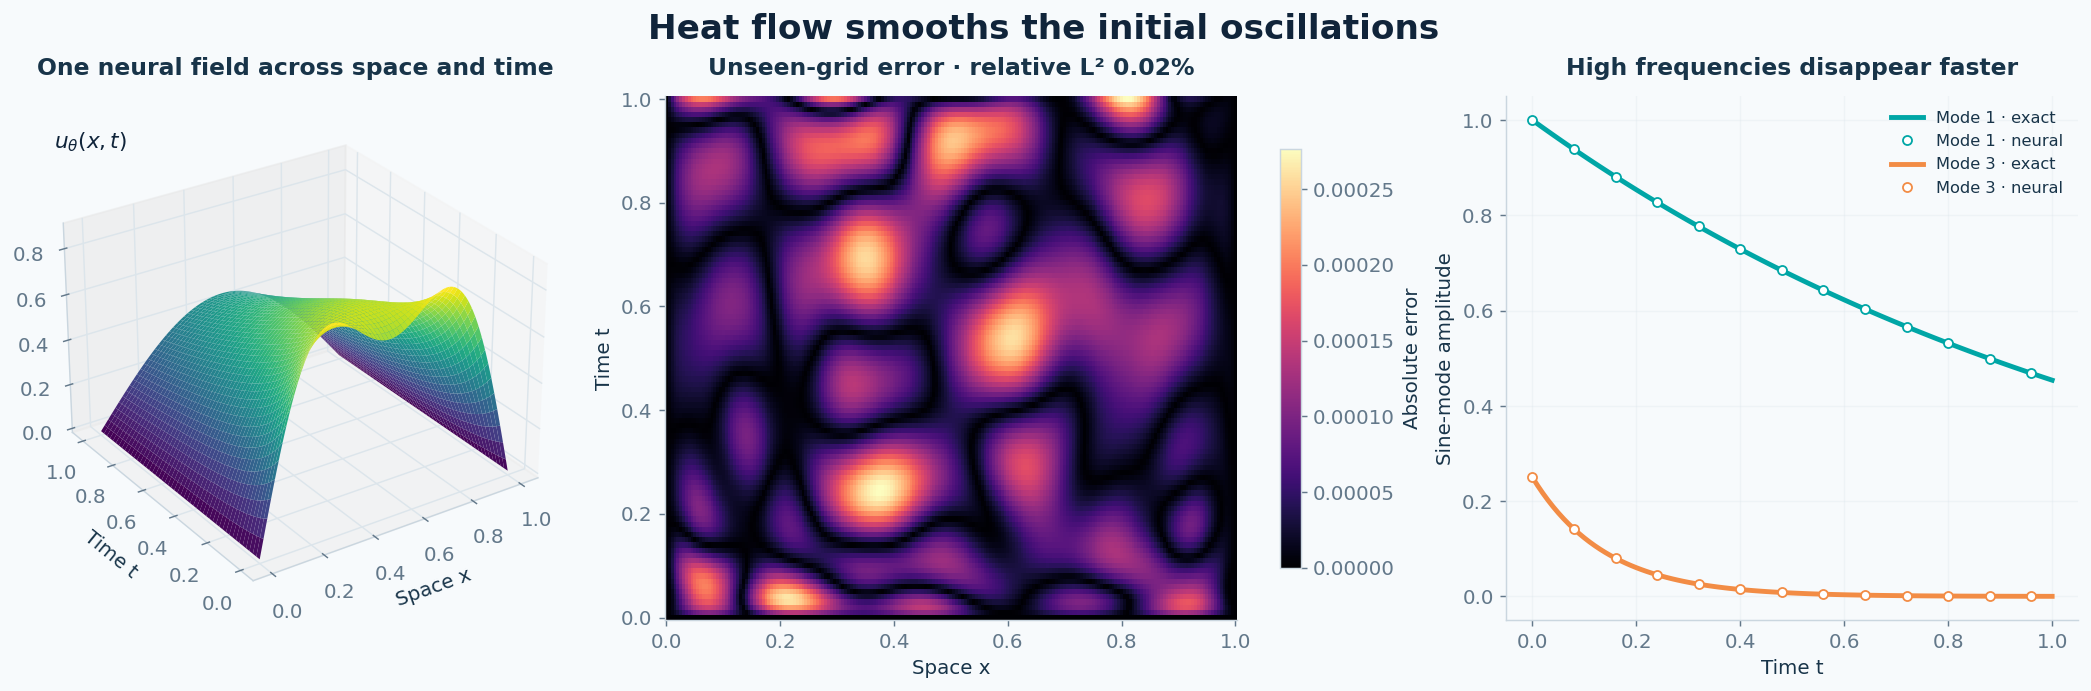

In [5]:
# Independent regular-grid validation; the reference was not used for optimization.
ht_x = np.linspace(0, 1, 201)
ht_t = np.linspace(0, 1, 101)
ht_X, ht_T = np.meshgrid(ht_x, ht_t)
ht_xt = torch.tensor(np.column_stack((ht_X.ravel(), ht_T.ravel())))
with torch.no_grad():
    ht_prediction = ht_model(ht_xt).numpy().reshape(ht_X.shape)
ht_exact = (np.exp(-ht_nu*np.pi**2*ht_T)*np.sin(np.pi*ht_X)
            + 0.25*np.exp(-9*ht_nu*np.pi**2*ht_T)*np.sin(3*np.pi*ht_X))
ht_error = ht_prediction-ht_exact
ht_integral = lambda z: np.trapezoid(np.trapezoid(z, ht_x, axis=1), ht_t)
ht_relative_l2 = float(np.sqrt(ht_integral(ht_error**2)/ht_integral(ht_exact**2)))
# Evaluate residuals in batches to keep higher-derivative memory modest.
ht_test_residual = np.concatenate([
    ht_residual(ht_model, block).detach().numpy().ravel()
    for block in ht_xt.split(2048)
]).reshape(ht_X.shape)
ht_residual_rms = float(np.sqrt(ht_integral(ht_test_residual**2)))
ht_amplitudes = {m: 2*np.trapezoid(ht_prediction*np.sin(m*np.pi*ht_X), ht_x, axis=1)
                 for m in (1, 3)}
ht_exact_amplitudes = {1: np.exp(-ht_nu*np.pi**2*ht_t),
                       3: 0.25*np.exp(-9*ht_nu*np.pi**2*ht_t)}
ht_initial_error = float(np.max(np.abs(ht_error[0])))
ht_boundary_error = float(np.max(np.abs(ht_prediction[:, [0, -1]])))
assert ht_initial_error < 1e-12 and ht_boundary_error < 1e-12
assert np.isfinite(ht_test_residual).all()
metrics.append(dict(experiment="Heat space-time PINN", relative_l2=ht_relative_l2,
                    residual_rms=ht_residual_rms, seconds=ht_history["seconds"]))
print(f"Independent relative space–time L² error: {ht_relative_l2:.3%}")
print(f"Independent PDE residual RMS: {ht_residual_rms:.3e}")
print(f"Initial / boundary errors: {ht_initial_error:.1e} / {ht_boundary_error:.1e}")

ht_fig = plt.figure(figsize=(16, 5.2), layout="constrained")
ht_ax0 = ht_fig.add_subplot(131, projection="3d")
ht_ax0.plot_surface(ht_X, ht_T, ht_prediction, cmap="viridis",
                    linewidth=0, antialiased=True, rcount=80, ccount=100)
ht_ax0.set(title="One neural field across space and time", xlabel="Space x",
            ylabel="Time t")
ht_ax0.text2D(0.04, 0.90, r"$u_\theta(x,t)$", transform=ht_ax0.transAxes,
              color=palette["navy"], fontsize=12)
ht_ax0.view_init(elev=28, azim=-124)
ht_ax0.set_box_aspect((1, 1, 0.7))
ht_ax1 = ht_fig.add_subplot(132)
ht_im = ht_ax1.pcolormesh(ht_X, ht_T, np.abs(ht_error), cmap="magma", shading="auto")
ht_fig.colorbar(ht_im, ax=ht_ax1, label="Absolute error", shrink=0.8)
ht_ax1.set(title=f"Unseen-grid error · relative L² {ht_relative_l2:.2%}",
            xlabel="Space x", ylabel="Time t")
ht_ax2 = ht_fig.add_subplot(133)
for ht_m, ht_color in [(1, palette["teal"]), (3, palette["orange"])]:
    ht_ax2.plot(ht_t, ht_exact_amplitudes[ht_m], color=ht_color, lw=2.7,
                label=f"Mode {ht_m} · exact")
    ht_ax2.plot(ht_t[::8], ht_amplitudes[ht_m][::8], 'o', color=ht_color,
                markerfacecolor="white", ms=5, label=f"Mode {ht_m} · neural")
ht_ax2.set(title="High frequencies disappear faster", xlabel="Time t", ylabel="Sine-mode amplitude")
ht_ax2.legend(fontsize=9)
ht_ax2.grid(alpha=0.3)
ht_fig.suptitle("Heat flow smooths the initial oscillations", fontsize=19,
                weight="bold", color=palette["navy"])
save_figure(ht_fig, "12_heat_space_time")

In [6]:
# A time slider compares profiles with a fixed vertical scale throughout.
ht_frame_indices = np.linspace(0, len(ht_t)-1, 41).astype(int)
ht_profile_fig = go.Figure(data=[
    go.Scatter(x=ht_x, y=ht_exact[0], mode="lines", name="Exact heat flow",
                line=dict(color=palette["teal"], width=4), fill="tozeroy",
                fillcolor="rgba(0,166,166,0.13)"),
    go.Scatter(x=ht_x[::4], y=ht_prediction[0, ::4], mode="markers", name="Neural field",
                marker=dict(color=palette["orange"], size=6,
                            line=dict(color="white", width=0.5))),
    go.Scatter(x=ht_x, y=ht_exact[0], mode="lines", name="Initial profile",
                line=dict(color=palette["muted"], dash="dot", width=1.6)),
], frames=[go.Frame(name=str(i), data=[go.Scatter(y=ht_exact[i]),
             go.Scatter(y=ht_prediction[i, ::4])], traces=[0, 1]) for i in ht_frame_indices])
ht_profile_fig.update_layout(
    title="Heat PINN · watch the fine-scale detail dissolve",
    xaxis=dict(title="Space x", range=[0, 1]),
    yaxis=dict(title="State u(x,t)", range=[-0.025, 1.05]),
    legend=dict(orientation="h", x=0, y=1.03),
    updatemenus=[dict(type="buttons", direction="left", x=0, y=1.18, buttons=[
        dict(label="▶ Diffuse", method="animate", args=[None,
             dict(frame=dict(duration=90, redraw=False), transition=dict(duration=0), fromcurrent=True)]),
        dict(label="Pause", method="animate", args=[[None], dict(mode="immediate",
             frame=dict(duration=0, redraw=False), transition=dict(duration=0))]),
    ])],
    sliders=[dict(currentvalue=dict(prefix="Time t = "), steps=[
        dict(label=f"{ht_t[i]:.2f}", method="animate", args=[[str(i)],
             dict(mode="immediate", frame=dict(duration=0, redraw=False), transition=dict(duration=0))])
        for i in ht_frame_indices])],
)
show_interactive(ht_profile_fig, "12_heat_profiles_interactive")

[Open interactive explorer](notebook_outputs/12_heat_profiles_interactive.html) — open locally in a browser; GitHub previews show the static plots.

The network is trained over the whole time interval, so we can evaluate its profiles
at any time after training. That convenience comes with a global optimization cost.
For a cost comparison, run a classical time integrator to the same accuracy. Here,
the initial and boundary conditions hold exactly; the independent residual and
solution checks measure the remaining approximation and training errors.

**Try:**

- Increase $\nu$ and rerun. The rapid initial transient becomes harder to resolve with a
  fixed set of uniformly distributed time samples. Does sampling more points near $t=0$ help?
- Replace the third mode by the fifth in **both** the initial condition and validation
  formula. Update its decay rate to $25\nu\pi^2$ and project onto the fifth mode.
- Double the final time, update the training and validation time coordinates consistently,
  and compare errors in the early and late parts of the interval.
- Compare with a finite-difference heat solver. Report wall time, state error, and how
  each method stores or reconstructs values between its sampled times.

## 13 · Train one network, solve a family of PDEs

A network can accept a PDE parameter as an input. Consider the reaction–diffusion family
$$-u_{xx}+\mu u=\pi^2\sin(\pi x),\qquad u(0;\mu)=u(1;\mu)=0,
\quad x\in[0,1],\quad\mu\in[0,30].$$
Its exact state is
$$u(x;\mu)=\frac{\pi^2}{\pi^2+\mu}\sin(\pi x).$$
Train one $u_\theta(x,\mu)=x(1-x)N_\theta(x,\mu)$ using residual samples in the
joint $(x,\mu)$ domain. The derivative $u_{xx}$ is taken **only with respect to the
spatial coordinate**; $\mu$ is a parameter, not a second spatial dimension.
No solution labels enter training. After training, new parameter values require only
network evaluation. This **parameter-conditioned PINN** is trained for the stated forcing family.
Changing the forcing would require new training or additional inputs.

For this example, the analytic formula is fastest. The network lets us study how
one training run can serve many parameter queries. We compare its errors with a
tridiagonal finite-difference solver; assessing speed would also require counting
the training cost.

In [7]:
PARAMETRIC_SETTINGS = dict(seed=1313, mu_max=30., collocation=768, width=32, depth=3,
                           adam_steps=1000, lbfgs_steps=220, fd_interior_nodes=63)
if RUN_MODE == "thorough":
    PARAMETRIC_SETTINGS["adam_steps"] *= 2
    PARAMETRIC_SETTINGS["lbfgs_steps"] *= 2
pa_cfg = PARAMETRIC_SETTINGS
torch.manual_seed(pa_cfg["seed"])

class pa_FamilyPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = mlp(2, width=pa_cfg["width"], depth=pa_cfg["depth"])
    def forward(self, xm):
        x, mu = xm[:, :1], xm[:, 1:2]
        features = torch.cat([2*x-1, 2*mu/pa_cfg["mu_max"]-1], dim=1)
        return x*(1-x)*self.net(features)

def pa_residual(model, xm):
    xm = xm.detach().requires_grad_()
    u = model(xm)
    ux = grad_scalar(u, xm)[:, :1]
    uxx = grad_scalar(ux, xm)[:, :1]
    return (-uxx+xm[:, 1:2]*u-np.pi**2*torch.sin(np.pi*xm[:, :1]))/np.pi**2

pa_model = pa_FamilyPINN()
pa_train = torch.quasirandom.SobolEngine(2, scramble=True, seed=pa_cfg["seed"]).draw(
                        pa_cfg["collocation"], dtype=torch.float64)
pa_train[:, 1] *= pa_cfg["mu_max"]
pa_history = train_model(pa_model, lambda: pa_residual(pa_model, pa_train).square().mean(),
                         pa_cfg["adam_steps"], pa_cfg["lbfgs_steps"])
pa_x = np.linspace(0, 1, 201)
pa_mu = np.linspace(0, pa_cfg["mu_max"], 61)
pa_X, pa_M = np.meshgrid(pa_x, pa_mu)
pa_inputs = torch.tensor(np.c_[pa_X.ravel(), pa_M.ravel()])
with torch.no_grad():
    pa_prediction = pa_model(pa_inputs).numpy().reshape(pa_X.shape)
pa_exact = np.pi**2/(np.pi**2+pa_M)*np.sin(np.pi*pa_X)
pa_error = pa_prediction-pa_exact
pa_param_errors = np.sqrt(np.trapezoid(pa_error**2, pa_x, axis=1)
                          / np.trapezoid(pa_exact**2, pa_x, axis=1))
pa_relative_l2 = float(np.sqrt(
    np.trapezoid(np.trapezoid(pa_error**2,pa_x,axis=1),pa_mu) /
    np.trapezoid(np.trapezoid(pa_exact**2,pa_x,axis=1),pa_mu)))
pa_normalized_rms = float(torch.sqrt(pa_residual(pa_model,pa_inputs).square().mean()).detach())
assert np.max(np.abs(pa_prediction[:,[0,-1]])) == 0
assert np.isfinite(pa_error).all()
metrics.append(dict(experiment="Parameter-conditioned PINN", relative_l2=pa_relative_l2,
                     maximum_parameter_error=float(pa_param_errors.max()),
                     normalized_residual_rms=pa_normalized_rms,seconds=pa_history["seconds"]))
print(f"One trained model, {len(pa_mu)} independently evaluated parameter slices.")
print(f"Relative L2 over (x, mu): {pa_relative_l2:.3e}; worst slice: {pa_param_errors.max():.3e}")
print(f"Training: {pa_history['seconds']:.1f} s; parameters: {sum(p.numel() for p in pa_model.parameters())}")

One trained model, 61 independently evaluated parameter slices.
Relative L2 over (x, mu): 3.578e-04; worst slice: 1.241e-03
Training: 8.2 s; parameters: 2241


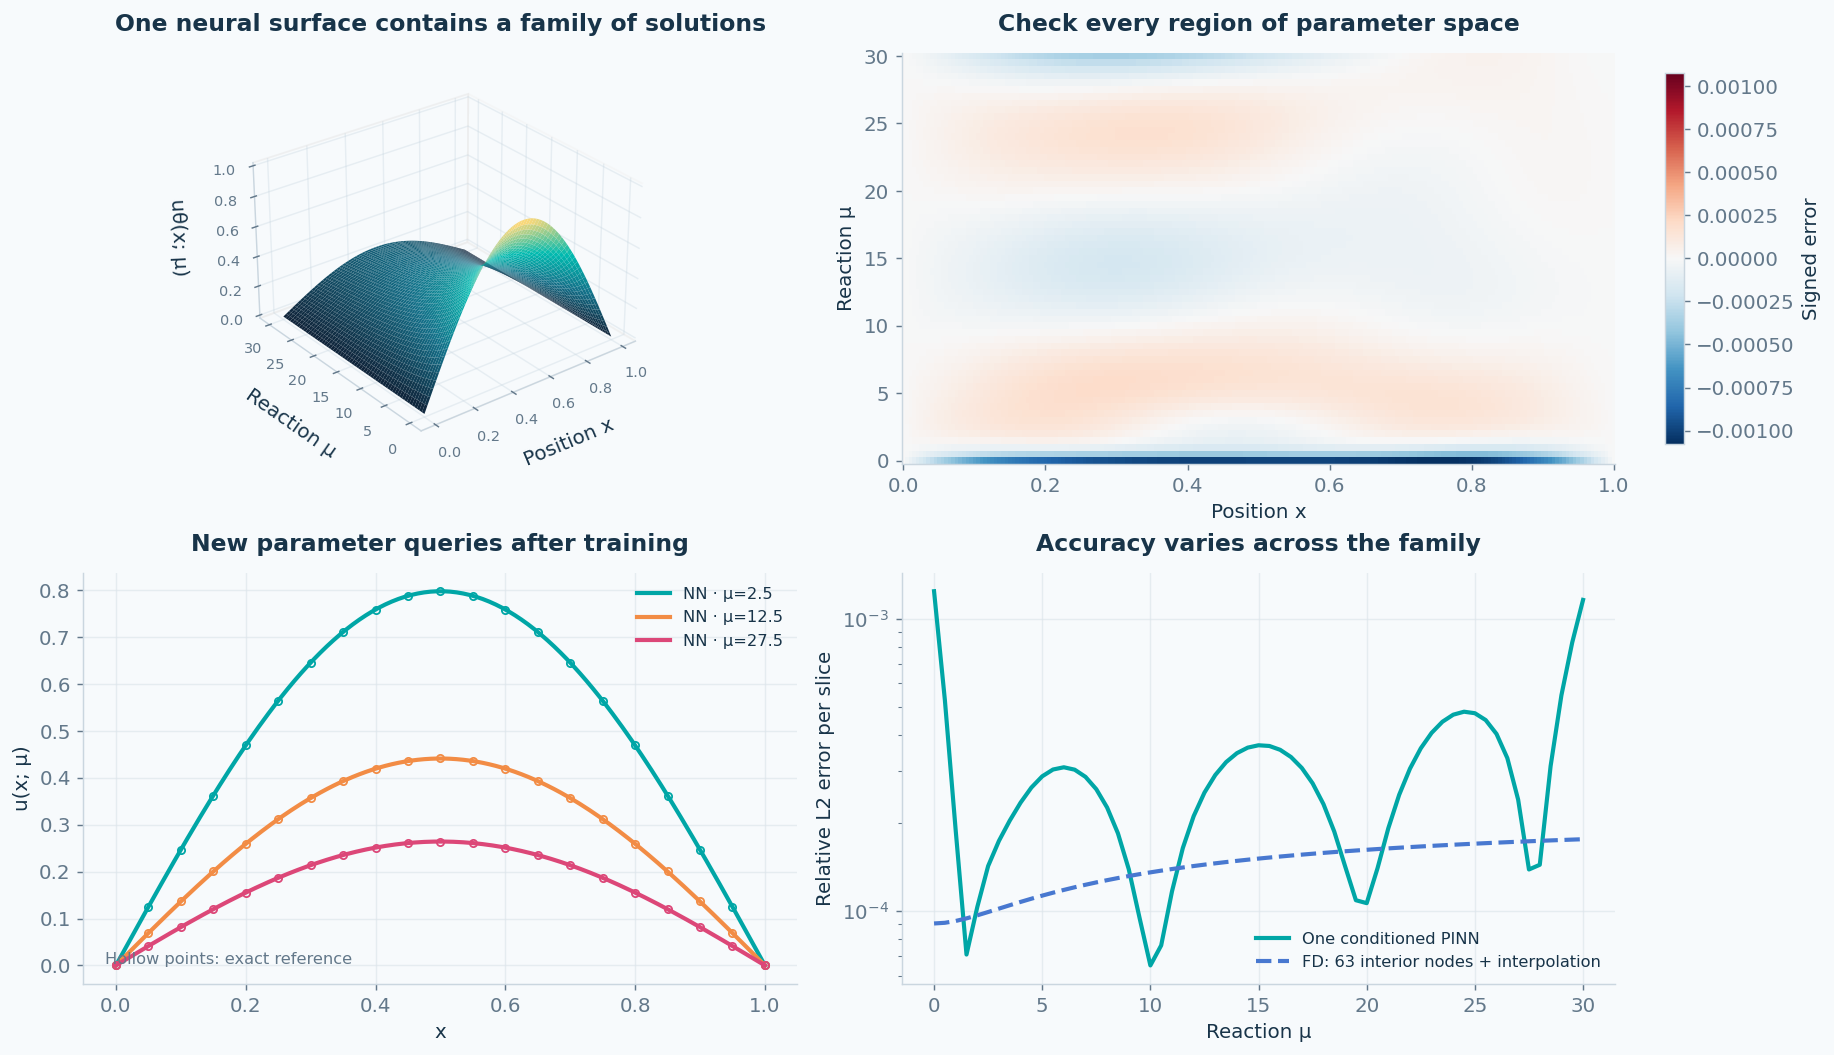

In [8]:
# Solve the same parameter slices with second-order finite differences.
pa_fd_n = pa_cfg["fd_interior_nodes"]
pa_fd_x = np.linspace(0,1,pa_fd_n+2)
pa_fd_h = 1/(pa_fd_n+1)
pa_fd_predictions = []
for mu in pa_mu:
    band = np.zeros((3,pa_fd_n))
    band[0,1:],band[1],band[2,:-1] = -1.,2.+mu*pa_fd_h**2,-1.
    values = np.r_[0.,solve_banded((1,1),band,pa_fd_h**2*np.pi**2*np.sin(np.pi*pa_fd_x[1:-1])),0.]
    pa_fd_predictions.append(np.interp(pa_x,pa_fd_x,values))
pa_fd_predictions = np.asarray(pa_fd_predictions)
pa_fd_errors = np.sqrt(np.trapezoid((pa_fd_predictions-pa_exact)**2,pa_x,axis=1)
                      / np.trapezoid(pa_exact**2,pa_x,axis=1))

fig = plt.figure(figsize=(14,8),layout="constrained")
ax=fig.add_subplot(221,projection="3d")
ax.plot_surface(pa_X,pa_M,pa_prediction,cmap=sea_cmap,linewidth=0,rcount=61,ccount=100)
style_3d(ax,"One neural surface contains a family of solutions")
ax.set(xlabel="Position x",ylabel="Reaction μ",zlabel="uθ(x; μ)")
ax=fig.add_subplot(222)
limit=np.max(np.abs(pa_error))
im=ax.pcolormesh(pa_x,pa_mu,pa_error,cmap="RdBu_r",vmin=-limit,vmax=limit,shading="auto")
fig.colorbar(im,ax=ax,label="Signed error",shrink=.9)
ax.set(title="Check every region of parameter space",xlabel="Position x",ylabel="Reaction μ")
ax=fig.add_subplot(223)
for idx,color in zip([5,25,55],[palette["teal"],palette["orange"],palette["pink"]]):
    ax.plot(pa_x,pa_prediction[idx],color=color,label=f"NN · μ={pa_mu[idx]:g}")
    ax.plot(pa_x[::10],pa_exact[idx,::10],"o",mfc="none",mec=color,ms=4)
ax.set(title="New parameter queries after training",xlabel="x",ylabel="u(x; μ)")
ax.text(.03,.05,"Hollow points: exact reference",transform=ax.transAxes,color=palette["muted"],fontsize=9)
ax.legend(fontsize=9);ax.grid()
ax=fig.add_subplot(224)
ax.semilogy(pa_mu,pa_param_errors,color=palette["teal"],label="One conditioned PINN")
ax.semilogy(pa_mu,pa_fd_errors,color=palette["blue"],ls="--",label="FD: 63 interior nodes + interpolation")
ax.set(title="Accuracy varies across the family",xlabel="Reaction μ",ylabel="Relative L2 error per slice")
ax.legend(fontsize=9);ax.grid()
save_figure(fig,"13_parametric_solver")

In [9]:
# Rotate the learned family, or colour the same surface by its error.
pa_surface = go.Figure([
    go.Surface(x=pa_X,y=pa_M,z=pa_prediction,colorscale="Viridis",name="Learned family",
                colorbar=dict(title="uθ"),visible=True),
    go.Surface(x=pa_X,y=pa_M,z=pa_prediction,surfacecolor=np.abs(pa_error),
                customdata=pa_error,colorscale="Magma",colorbar=dict(title="|Error|"),
                name="Error colours",visible=False,
                hovertemplate="x=%{x:.3f}<br>μ=%{y:.2f}<br>uθ=%{z:.5f}<br>Error=%{customdata:.2e}<extra></extra>")])
pa_surface.update_layout(title="One network · a continuous family of PDE solutions",
    scene=dict(xaxis_title="x",yaxis_title="Reaction μ",zaxis_title="uθ(x; μ)",
               aspectratio=dict(x=1,y=1,z=.65),uirevision="parameter-family"),
    updatemenus=[dict(buttons=[
        dict(label="Learned family",method="update",args=[dict(visible=[True,False])]),
        dict(label="Error colours",method="update",args=[dict(visible=[False,True])])])])
show_interactive(pa_surface,"13_parametric_interactive")

[Open interactive explorer](notebook_outputs/13_parametric_interactive.html) — open locally in a browser; GitHub previews show the static plots.

**Try:** widen the parameter interval while keeping the training budget fixed. Where
does the worst error occur? Evaluate beyond $\mu=30$ and label it as **extrapolation**.
Then change the forcing to include a second sine mode: the current model has not been
trained for that new family. How would you add forcing coefficients as extra inputs?

## Save this notebook's results

This cell records versions, settings, diagnostics and computed fields, and builds a
local gallery. Report filenames include this notebook's part number, so notebooks
can run independently in any order without overwriting each other's reports.

In [10]:
# Keep reports separate so running one notebook cannot replace another's results.
PART = '07_time_and_parameters'
summary_metrics = list(metrics)

report = dict(part=PART, versions=versions, run_mode=RUN_MODE, seed=SEED, budgets=BUDGET,
    device="cpu", dtype=str(torch.get_default_dtype()), settings=dict(heat=HEAT_SETTINGS, parametric=PARAMETRIC_SETTINGS),
    static_figures=FIGURE_NAMES, interactive_figures=INTERACTIVE_NAMES,
    metrics=summary_metrics, elapsed_seconds=time.perf_counter()-NOTEBOOK_START)
(OUTPUT_DIR / f"run_summary_{PART}.json").write_text(json.dumps(report, indent=2))
np.savez_compressed(OUTPUT_DIR / f"computed_fields_{PART}.npz", heat_x=ht_x, heat_t=ht_t, heat_prediction=ht_prediction,
        heat_exact=ht_exact, heat_residual=ht_test_residual,
        parametric_x=pa_x, parametric_mu=pa_mu, parametric_prediction=pa_prediction,
        parametric_exact=pa_exact, parametric_fd_prediction=pa_fd_predictions)

from html import escape
cards = []
for name in FIGURE_NAMES:
    title = escape(name.replace("_", " ").title())
    cards.append(f'<figure><a href="{name}.png"><img src="{name}.png" alt="{title}"></a>'
                 f'<figcaption>{title} · <a href="{name}.pdf">PDF</a></figcaption></figure>')
links = "".join(f'<li><a href="{name}.html">{escape(name.replace("_", " ").title())}</a></li>'
                for name in INTERACTIVE_NAMES)
page = ('<!doctype html><html lang="en"><meta charset="utf-8">'
        '<meta name="viewport" content="width=device-width, initial-scale=1">'
        '<title>Neural PDE Laboratory</title><style>'
        'body{font-family:system-ui;color:#273442;max-width:1100px;margin:auto;padding:32px}'
        'img{max-width:100%}figure{margin:32px 0}a{color:#4d708a}</style>'
        f'<h1>Neural PDE Laboratory · {escape(PART)}</h1><ul>' + links + '</ul>' + "".join(cards) + '</html>')
(OUTPUT_DIR / f"index_{PART}.html").write_text(page)
print(f"Completed in {report['elapsed_seconds']:.1f} seconds.")
print(f"Saved {len(FIGURE_NAMES)} figure sets and {len(INTERACTIVE_NAMES)} interactive explorers.")
print(f"Reports: run_summary_{PART}.json, computed_fields_{PART}.npz, index_{PART}.html")
for row in summary_metrics:
    print(f"{row['experiment']:32s} relative L2 = {row['relative_l2']:.3e}")

Completed in 33.3 seconds.
Saved 2 figure sets and 2 interactive explorers.
Reports: run_summary_07_time_and_parameters.json, computed_fields_07_time_and_parameters.npz, index_07_time_and_parameters.html
Heat space-time PINN             relative L2 = 1.812e-04
Parameter-conditioned PINN       relative L2 = 3.578e-04


[Previous notebook](Neural_PDE_06_features_and_sampling.ipynb) · [Laboratory index](Neural_PDE_Laboratory.ipynb)